In [1]:
!pip install pandas numpy scikit-learn matplotlib seaborn

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor

print("library loaded successfully")

library loaded successfully


In [1]:
from google.colab import files
uploaded = files.upload()

Saving calories.csv to calories.csv
Saving exercise.csv to exercise.csv


In [4]:
calories = pd.read_csv('calories.csv')
exercise = pd.read_csv('exercise.csv')

In [5]:
df = pd.merge(calories, exercise, on='User_ID')
df.head()

,User_ID,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,66.0,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,26.0,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,71.0,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,35.0,female,27,154.0,58.0,10.0,81.0,39.8


In [6]:
calories.head()

,User_ID,Calories
0,14733363,231.0
1,14861698,66.0
2,11179863,26.0
3,16180408,71.0
4,17771927,35.0


In [7]:
exercise.head()

,User_ID,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,female,27,154.0,58.0,10.0,81.0,39.8


In [8]:
print("shape:", df.shape)
print("\nColumn names: ", df.columns.tolist())
df.head()

shape: (15000, 9)

Column names:  ['User_ID', 'Calories', 'Gender', 'Age', 'Height', 'Weight', 'Duration', 'Heart_Rate', 'Body_Temp']


,User_ID,Calories,Gender,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,14733363,231.0,male,68,190.0,94.0,29.0,105.0,40.8
1,14861698,66.0,female,20,166.0,60.0,14.0,94.0,40.3
2,11179863,26.0,male,69,179.0,79.0,5.0,88.0,38.7
3,16180408,71.0,female,34,179.0,71.0,13.0,100.0,40.5
4,17771927,35.0,female,27,154.0,58.0,10.0,81.0,39.8


In [15]:
df = df.drop(["User_ID", "Gender"], axis = 1)
df.head()

,Calories,Age,Height,Weight,Duration,Heart_Rate,Body_Temp
0,231.0,68,190.0,94.0,29.0,105.0,40.8
1,66.0,20,166.0,60.0,14.0,94.0,40.3
2,26.0,69,179.0,79.0,5.0,88.0,38.7
3,71.0,34,179.0,71.0,13.0,100.0,40.5
4,35.0,27,154.0,58.0,10.0,81.0,39.8


In [16]:
x = df.drop("Calories", axis=1)
y = df["Calories"]

print("shape of x:", x.shape)
print("shape of y:", y.shape)

shape of x: (15000, 6)
shape of y: (15000,)


In [17]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(f"training samples: {len(x_train)}")
print(f"testing samples: {len(x_test)}")

training samples: 12000
testing samples: 3000


In [18]:
model = LinearRegression()
model.fit(x_train, y_train)

print("Model trained successfully")

Model trained successfully


In [21]:
y_pred = model.predict(x_test)

for i in range(5):
  print(f"Predicted: {y_pred[i]:.2f}, Actual: {y_test.iloc[i]}")

Predicted: 170.84, Actual: 173.0
Predicted: 192.10, Actual: 189.0
Predicted: 56.83, Actual: 53.0
Predicted: 155.47, Actual: 161.0
Predicted: 212.27, Actual: 226.0


In [22]:
mae = mean_absolute_error(y_test, y_pred)

print(f"Mean Absolute Error: {mae:.2f}")


Mean Absolute Error: 8.44


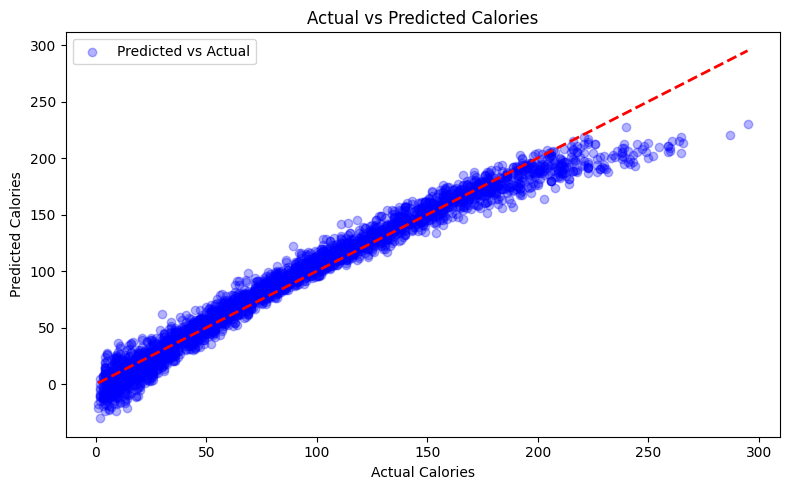

In [24]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred, alpha = 0.3, color='blue', label='Predicted vs Actual')
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Calories')
plt.ylabel('Predicted Calories')
plt.title('Actual vs Predicted Calories')
plt.tight_layout()
plt.legend()
plt.show()

In [30]:
my_workout = pd.DataFrame({
    'Age':        [18],    # your age
    'Height':     [150],   # in cm
    'Weight':     [45],    # in kg
    'Duration':   [30],    # minutes of exercise
    'Heart_Rate': [120],   # approximate BPM during workout
    'Body_Temp':  [38.5]   # body temp in celsius (normal workout ~38-39)
})

prediction = model.predict(my_workout)
print(f"Estimated calories burned: {prediction[0]:.1f} kcal")

Estimated calories burned: 244.1 kcal


#Random Forest Model

In [32]:
rf_model = RandomForestRegressor(n_estimators=100, random_state=42)


In [34]:
rf_model.fit(x_train, y_train)


RandomForestRegressor(random_state=42)

In [35]:
rf_pred = rf_model.predict(x_test)

In [36]:
rf_mae = mean_absolute_error(y_test, rf_pred)
lr_mae = mean_absolute_error(y_test, y_pred)

print(f"Linear Regression MAE:  {lr_mae:.2f} calories")
print(f"Random Forest MAE:      {rf_mae:.2f} calories")
print(f"Improvement:            {lr_mae - rf_mae:.2f} calories better!")

Linear Regression MAE:  8.44 calories
Random Forest MAE:      2.51 calories
Improvement:            5.93 calories better!


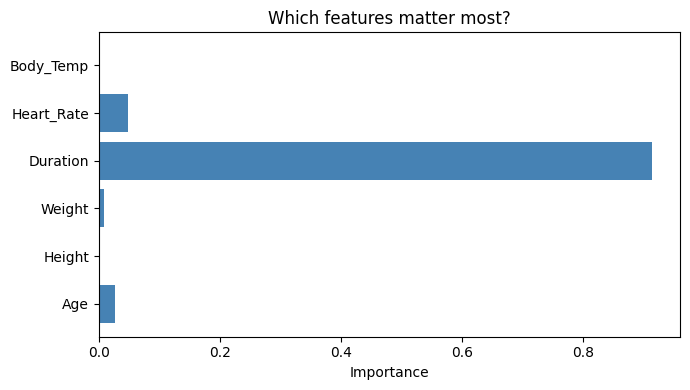

In [37]:
features = x.columns.tolist()

importances = rf_model.feature_importances_

plt.figure(figsize=(7, 4))
plt.barh(features, importances, color='steelblue')
plt.xlabel("Importance")
plt.title("Which features matter most?")
plt.tight_layout()
plt.show()

In [38]:
!pip install gradio

In [39]:
import gradio as gr

def predict_calories(age, height, weight, duration, heart_rate, body_temp):
    input_data = pd.DataFrame({
        'Age':        [age],
        'Height':     [height],
        'Weight':     [weight],
        'Duration':   [duration],
        'Heart_Rate': [heart_rate],
        'Body_Temp':  [body_temp]
    })
    result = rf_model.predict(input_data)[0]
    return f"🔥 Estimated Calories Burned: {result:.1f} kcal"

app = gr.Interface(
    fn=predict_calories,
    inputs=[
        gr.Slider(10, 80,  value=22,   label="Age"),
        gr.Slider(140, 210, value=170, label="Height (cm)"),
        gr.Slider(40, 150,  value=70,  label="Weight (kg)"),
        gr.Slider(5, 120,   value=30,  label="Duration (minutes)"),
        gr.Slider(60, 180,  value=110, label="Heart Rate (BPM)"),
        gr.Slider(37, 41,   value=38.5,label="Body Temp (°C)", step=0.1),
    ],
    outputs=gr.Textbox(label="Prediction"),
    title="🏋️ Calorie Burn Predictor",
    description="Enter your workout stats and get an instant calorie estimate!"
)

app.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://2fc9e797f4d78d77d7.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
